In [210]:
from bcb import TaxaJuros as txj
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from datetime import datetime as dt
from PIL import Image

In [211]:
memoria = txj()

In [212]:
ep = memoria.get_endpoint('TaxasJurosDiariaPorInicioPeriodo')

In [213]:
df_cheque = (ep.query().filter(ep.Segmento == 'PESSOA FÍSICA',
                               ep.Modalidade ==
                               'CHEQUE ESPECIAL - PRÉ-FIXADO').collect())

In [214]:
df_cheque['InicioPeriodo'] = pd.to_datetime(df_cheque['InicioPeriodo'])


In [215]:
df_cheque.drop(columns=['FimPeriodo', 'cnpj8', 'Modalidade',
                        'Segmento', 'TaxaJurosAoAno', 'Posicao'],
               inplace=True)

In [ ]:
df_cheque

In [216]:
mercado = df_cheque.groupby(df_cheque['InicioPeriodo'])['TaxaJurosAoMes'].mean().round(2)

In [217]:
df_cheque['InstituicaoFinanceira'].unique()

array(['BCO RIBEIRAO PRETO S.A.', 'BCO ALFA S.A.', 'BCO BMG S.A.',
       'BCO SOFISA S.A.', 'BCO MODAL S.A.', 'BANCO SICOOB S.A.',
       'BCO DO NORDESTE DO BRASIL S.A.', 'BCO CCB BRASIL S.A.',
       'BCO ABC BRASIL S.A.', 'BCO BANESTES S.A.', 'BANCO ORIGINAL',
       'BCO DO EST. DO PA S.A.', 'CAIXA ECONOMICA FEDERAL',
       'BCO SAFRA S.A.', 'BCO DAYCOVAL S.A', 'BCO DA AMAZONIA S.A.',
       'BCO DO BRASIL S.A.', 'BCO DO ESTADO DO RS S.A.', 'BANCO INTER',
       'BANCO BTG PACTUAL S.A.', 'BCO RENDIMENTO S.A.', 'BANCO PAN',
       'BCO SANTANDER (BRASIL) S.A.', 'BCO DO EST. DE SE S.A.',
       'BCO AGIBANK S.A.', 'BCO C6 S.A.', 'BCO TRIANGULO S.A.',
       'BCO MERCANTIL DO BRASIL S.A.', 'ITAÚ UNIBANCO S.A.',
       'BCO BRADESCO S.A.', 'BCO DIGIMAIS S.A.', 'BANCO SEMEAR',
       'BCO LUSO BRASILEIRO S.A.', 'BCO PAULISTA S.A.', 'BCO PINE S.A.',
       'BANCOSEGURO S.A.', 'OMNI BANCO S.A.',
       'BCO INDUSTRIAL DO BRASIL S.A.', 'BRB - BCO DE BRASILIA S.A.',
       'BCO CEDULA S.A

In [218]:
df_bancos = df_cheque.pivot(index='InicioPeriodo',
                            columns='InstituicaoFinanceira',
                            values='TaxaJurosAoMes').reset_index()

In [219]:
df_bancos.drop(columns=[
    'BCO RIBEIRAO PRETO S.A.', 'BCO ALFA S.A.', 'BCO PAULISTA S.A.',
    'BANCO SEMEAR', 'BCO BMG S.A.', 'BCO SOFISA S.A.', 'BANCO SICOOB S.A.',
    'BCO MODAL S.A.', 'BCO DO NORDESTE DO BRASIL S.A.', 'BCO CCB BRASIL S.A.',
    'BCO PINE S.A.', 'BCO BANESTES S.A.', 'BCO DO EST. DO PA S.A.',
    'BCO SAFRA S.A.', 'BCO LUSO BRASILEIRO S.A.',
    'BCO DA AMAZONIA S.A.', 'BCO DAYCOVAL S.A',
    'BCO DO ESTADO DO RS S.A.', 'BANCO PAN',
    'BANCO ORIGINAL', 'BCO DO EST. DE SE S.A.', 'BCO RENDIMENTO S.A.',
    'BCO AGIBANK S.A.', 'BCO C6 S.A.', 'BCO TRIANGULO S.A.',
    'BCO MERCANTIL DO BRASIL S.A.', 'BCO DIGIMAIS S.A.', 'BANCOSEGURO S.A.',
    'BANCO BTG PACTUAL S.A.', 'OMNI BANCO S.A.',
    'BCO INDUSTRIAL DO BRASIL S.A.', 'BCO ABC BRASIL S.A.',
    'BRB - BCO DE BRASILIA S.A.', 'BCO CEDULA S.A.', 'PARANA BCO S.A.',
    'BCO BS2 S.A.', 'BCO CREFISA S.A.', 'BCO FIBRA S.A.', 'BCO FATOR S.A.',
    'SOCIAL BANK S/A', 'NOVO BCO CONTINENTAL S.A. - BM', 'BANCO VOITER',
    'BCO J.P. MORGAN S.A.', 'BCO LA NACION ARGENTINA', 'BCO CITIBANK S.A.',
    'BANIF BRASIL BM S.A.', 'KIRTON BANK', 'BCO DA CHINA BRASIL S.A.',
    'PICPAY BANK - BANCO MÚLTIPLO S.A', 'BCO BVA S.A.',
    'BCO CRUZEIRO DO SUL S.A.', 'BCO PROSPER S.A.', 'BCO VOTORANTIM S.A.'],
    inplace=True
)

In [ ]:
df_bancos

In [220]:
df_bancos.rename(columns={'BANCO INTER': 'Inter', 'BCO BRADESCO S.A.' : 'Bradesco'
    , 'BCO SANTANDER (BRASIL) S.A.' : 'Santander', 'CAIXA ECONOMICA FEDERAL': 'Caixa',
    'ITAÚ UNIBANCO S.A.':'Itaú','BCO DO BRASIL S.A.': 'Bco do Brasil', 'InstituicaoFinanceira' :'index'       
}, inplace = True)

In [221]:
graph = df_bancos[df_bancos['InicioPeriodo'] >= '2020-01-01']

In [222]:
graph.set_index(graph['InicioPeriodo'], inplace=True)

In [224]:
graph.drop(columns=['InicioPeriodo'], inplace= True)

C:\Users\Hugo Martins\AppData\Local\Temp\ipykernel_2124\4188141071.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graph.drop(columns=['InicioPeriodo'], inplace= True)


In [ ]:
graph

In [ ]:
graph.info()

In [225]:
market = f'{"{:.2%}".format(mercado.iloc[-1]/100)} Mercado'
market

'6.80% Mercado'

In [ ]:
plt.style.available

In [226]:
data = graph.index.to_pydatetime()

In [227]:
nomes = {
    'Bradesco' : {
        'label': f'{"{:.2%}".format(graph["Bradesco"].iloc[-1]/100)} Bradesco',
        'color': 'red',
    },
    'Itaú': {
        'label': f'{"{:.2%}".format(graph["Itaú"].iloc[-1]/100)} Itaú',
        'color': 'orange',
    },
    'Santander': {
        'label': f'{"{:.2%}".format(graph["Santander"].iloc[-1]/100)} Santander',
        'color': 'green',
    },
    'Inter': {
        'label': f'{"{:.2%}".format(graph["Inter"].iloc[-1]/100)} Inter',
        'color': 'grey',
    },
    'Bco do Brasil' : {
        'label': f'{"{:.2%}".format(graph["Bco do Brasil"].iloc[-1]/100)} BB',
        'color': '#DEE012',
    },
    'Caixa': {
        'label': f'{"{:.2%}".format(graph["Caixa"].iloc[-1]/100)} Caixa',
        'color': 'blue',
    }
}

nome_att = nomes.copy()


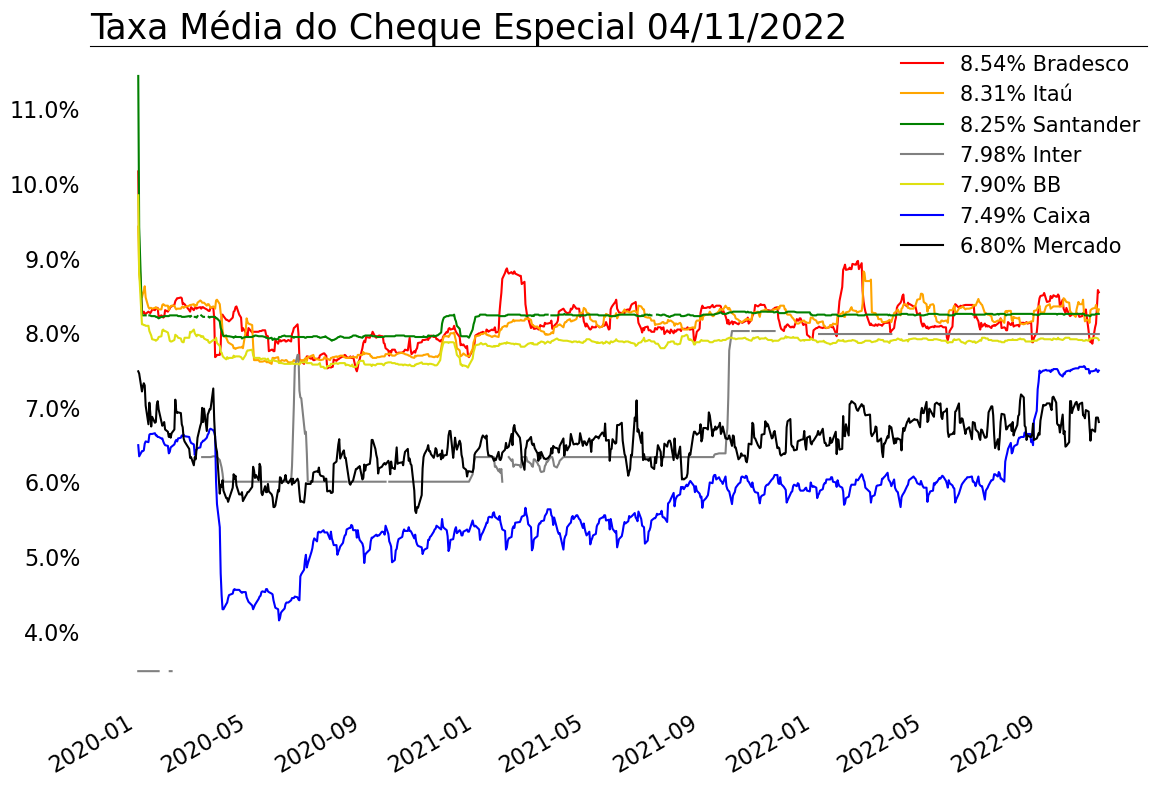

In [228]:
# plt.style.use('default')
plt.figure(figsize=[12,8])
plt.title(f'Taxa Média do Cheque Especial {graph.index[-1].strftime("%d/%m/%Y")}', loc = 'left', fontsize=25)

for bancos,infos in nomes.items():
    maxi = max(graph[nome_att.keys()].iloc[-1])
    if graph[bancos].iloc[-1] == maxi:
        nome_att.pop(bancos)
    plt.plot(data,graph[bancos], label=nomes[bancos]['label'], c=nomes[bancos]['color'])
            

plt.plot(data, mercado[mercado.index >= '2020-01-01'], 'black',label=market)


# Get the current axes
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Get the current figure
plt.gcf().autofmt_xdate()

# If you want to see all the rcParams https://matplotlib.org/stable/tutorials/introductory/customizing.html
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.bottom'] = False
plt.rcParams['axes.spines.top'] = True
plt.rcParams['ytick.left'] = False
plt.rcParams['xtick.bottom'] = False
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16


plt.legend(bbox_to_anchor=(0.75, 0.65), fontsize=15, frameon=False)
plt.tight_layout()
plt.show()